In [2]:
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import TPESampler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic' # 윈도우는 'Malgun Gothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ==============================================================================
# [함수 1] RFM 및 주기성 파생변수 생성
# ==============================================================================
def create_rfm_features(trans_df, base_date_str='2023-12-31'):
    trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
    base_date = pd.to_datetime(base_date_str)
    
    def get_rfm_by_days(days, prefix):
        cutoff = base_date - pd.Timedelta(days=days)
        temp = trans_df[trans_df['trans_date'] >= cutoff]
        return temp.groupby('customer_id').agg(
            freq=(f'trans_id', 'count'),
            money=(f'trans_amount', 'sum')
        ).rename(columns={'freq': f'freq_{prefix}', 'money': f'money_{prefix}'})

    periods = {7: '7d', 15: '15d', 30: '30d', 60: '60d', 90: '90d', 180: '180d'}
    rfm_frames = [get_rfm_by_days(days, prefix) for days, prefix in periods.items()]
        
    rfm_base = trans_df.groupby('customer_id').agg(
        recency=('trans_date', lambda x: (base_date - x.max()).days),
        total_freq=('trans_id', 'count'),
        total_money=('trans_amount', 'sum')
    ).reset_index()
    
    for frame in rfm_frames:
        rfm_base = rfm_base.merge(frame, on='customer_id', how='left')
    rfm_base.fillna(0, inplace=True)

    trans_df = trans_df.sort_values(['customer_id', 'trans_date'])
    trans_df['days_diff'] = trans_df.groupby('customer_id')['trans_date'].diff().dt.days
    interval_stats = trans_df.groupby('customer_id')['days_diff'].agg(['mean', 'std']).reset_index()
    interval_stats.columns = ['customer_id', 'avg_interval', 'interval_std']
    interval_stats.fillna(0, inplace=True)
    
    rfm_df = rfm_base.merge(interval_stats, on='customer_id', how='left')
    
    # 킬러 파생변수 세트
    rfm_df['relative_recency'] = rfm_df['recency'] / (rfm_df['avg_interval'] + 1e-6)
    rfm_df['consistency_risk'] = rfm_df['relative_recency'] * (1 / (rfm_df['interval_std'] + 1))
    rfm_df['short_term_drop_7d'] = (rfm_df['money_30d'] / 4) - rfm_df['money_7d']
    rfm_df['short_term_drop_15d'] = (rfm_df['money_30d'] / 2) - rfm_df['money_15d']
    rfm_df['avg_ticket_size'] = np.log1p(rfm_df['total_money'] / (rfm_df['total_freq'] + 1e-6))
    
    return rfm_df

In [4]:
# ==============================================================================
# [함수 2] 재무/부채 파생변수 생성
# ==============================================================================
def create_finance_features(finance_df):
    fin_df = finance_df.copy()
    fin_df['total_debt'] = fin_df['card_cash_service_amt'] + fin_df['card_loan_amt'] + fin_df['total_loan_balance']
    fin_df['debt_to_asset_ratio'] = np.log1p(fin_df['total_debt'] / (fin_df['total_deposit_balance'] + 1))
    fin_df['has_card_loan'] = (fin_df['card_loan_amt'] > 0).astype(int)
    fin_df['has_overdue'] = (fin_df['fin_overdue_days'] > 0).astype(int)
    return fin_df

In [12]:
# ==============================================================================
# [함수 3] 취향 일치도 파생변수 생성
# ==============================================================================
def create_preference_features(info_df, trans_df, actual_cat_col='item_category'):
    temp_trans = trans_df.merge(info_df[['customer_id', 'prefer_category']], on='customer_id', how='left')
    temp_trans['is_pref_spend'] = (temp_trans[actual_cat_col] == temp_trans['prefer_category']).astype(int)
    temp_trans['pref_category_amount'] = temp_trans['trans_amount'] * temp_trans['is_pref_spend']

    pref_match_df = temp_trans.groupby('customer_id').agg(
        pref_spend_sum=('pref_category_amount', 'sum'),
        total_spend=('trans_amount', 'sum')
    ).reset_index()

    pref_match_df['pref_spend_ratio'] = pref_match_df['pref_spend_sum'] / (pref_match_df['total_spend'] + 1e-6)
    return pref_match_df[['customer_id', 'pref_spend_ratio']]

In [15]:
# ==============================================================================
# [함수 4] 전처리 파이프라인
# ==============================================================================
def preprocess_pipeline(info_df, finance_df, trans_df, targets_df):
    print("▶️ 데이터를 병합하고 파생변수를 생성합니다...")
    rfm_df = create_rfm_features(trans_df)
    fin_df = create_finance_features(finance_df)
    pref_df = create_preference_features(info_df, trans_df, actual_cat_col='item_category')
    
    df = info_df.merge(rfm_df, on='customer_id', how='left')
    df = df.merge(fin_df, on='customer_id', how='left')
    df = df.merge(pref_df, on='customer_id', how='left')
    df = df.merge(targets_df, on='customer_id', how='inner')
    df.fillna(0, inplace=True)
    
    cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')
            
    drop_cols = ['customer_id', 'target_churn', 'target_ltv', 'join_date', 'trans_date']
    features = [c for c in df.columns if c not in drop_cols]
    
    X = df[features]
    y = df['target_churn']
    return X, y, features

In [13]:
# ==============================================================================
# [함수 5] Optuna를 활용한 XGBoost 튜닝 (K-Fold 제외, 단순 Hold-out)
# ==============================================================================
def optimize_xgboost(X_train, X_valid, y_train, y_valid):
    print("\n🚀 K-Fold를 제외한 빠른 XGBoost Optuna 튜닝을 시작합니다...")
    
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'tree_method': 'hist',          # 범주형 처리 필수
            'enable_categorical': True,     # 범주형 처리 필수
            'random_state': 42,
            'n_jobs': -1
        }
        
        model = xgb.XGBClassifier(**param)
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        
        preds = model.predict_proba(X_valid)[:, 1]
        return roc_auc_score(y_valid, preds)

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=30) 
    
    print(f"✅ 최적의 ROC-AUC 점수: {study.best_value:.4f}")
    return study.best_params

In [ ]:
# ==============================================================================
# 🎯 메인 실행 블록 (여기부터 주석을 풀고 실행하세요)
# ==============================================================================
# 1. 데이터 로드 (경로를 실제 환경에 맞게 수정하세요)
info_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_customer_info.csv')
finance_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_finance_profile.csv')
trans_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_transaction_history.csv')
targets_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_targets.csv')

In [16]:
# 2. 전처리 실행
X, y, feature_names = preprocess_pipeline(info_df, finance_df, trans_df, targets_df)

# 3. Train / Valid 단일 분할 (K-Fold 대신)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

▶️ 데이터를 병합하고 파생변수를 생성합니다...


In [17]:
# 4. 하이퍼파라미터 최적화 (XGBoost)
best_params = optimize_xgboost(X_train, X_valid, y_train, y_valid)

[I 2026-04-13 14:12:45,417] A new study created in memory with name: no-name-cede9155-6011-4401-901b-032a60a9ce37



🚀 K-Fold를 제외한 빠른 XGBoost Optuna 튜닝을 시작합니다...


[I 2026-04-13 14:12:46,307] Trial 0 finished with value: 0.7647532974399869 and parameters: {'n_estimators': 250, 'learning_rate': 0.08927180304353628, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481}. Best is trial 0 with value: 0.7647532974399869.
[I 2026-04-13 14:12:46,778] Trial 1 finished with value: 0.7760302911315698 and parameters: {'n_estimators': 123, 'learning_rate': 0.07348118405270448, 'max_depth': 7, 'min_child_weight': 8, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978}. Best is trial 1 with value: 0.7760302911315698.
[I 2026-04-13 14:12:47,610] Trial 2 finished with value: 0.7873518838081046 and parameters: {'n_estimators': 433, 'learning_rate': 0.016305687346221478, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.721696897183815, 'colsample_bytree': 0.8099025726528951}. Best is trial 2 with value: 0.7873518838081046.
[I 2026-04-13 14:12:48,503] Trial 3 finished with value: 0.7855

✅ 최적의 ROC-AUC 점수: 0.7878


In [18]:
# 5. 최종 모델 학습
best_params['tree_method'] = 'hist'
best_params['enable_categorical'] = True
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# 예측 수행
valid_preds = final_model.predict_proba(X_valid)[:, 1]
print(f"\n🔥 최종 Validation ROC-AUC Score: {roc_auc_score(y_valid, valid_preds):.4f}")


🔥 최종 Validation ROC-AUC Score: 0.7878


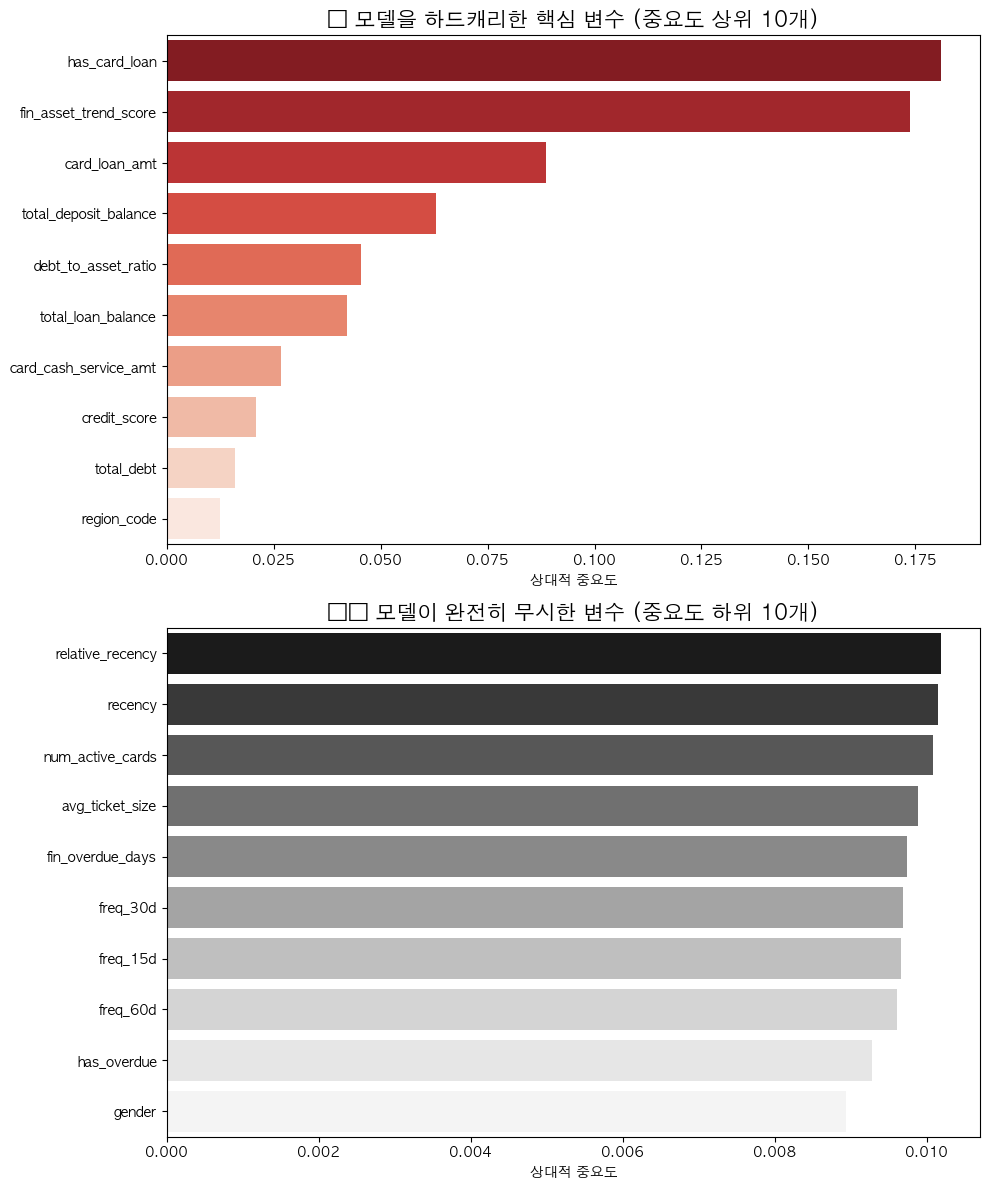


[💡 참고] 삭제를 고려해볼 만한 하위 10개 피처 리스트:
['relative_recency', 'recency', 'num_active_cards', 'avg_ticket_size', 'fin_overdue_days', 'freq_30d', 'freq_15d', 'freq_60d', 'has_overdue', 'gender']


In [22]:
# ==============================================================================
# 📊 [시각화 1] 피처 중요도 정밀 분석 (상위 10개 vs 하위 10개)
# ==============================================================================
# 1. 피처 중요도를 데이터프레임으로 묶기
feature_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_model.feature_importances_
})

# 2. 중요도 내림차순(가장 높은 것부터)으로 정렬
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 상위 10개 / 하위 10개 추출
top_10_features = feature_imp.head(10)
bottom_10_features = feature_imp.tail(10) # 꼬리 부분 10개

# 3. 위아래로 2개의 그래프를 동시에 그리기 (가로 10, 세로 12 사이즈)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# [상위 10개] 빨간색 톤으로 시각화
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='Reds_r', ax=axes[0])
axes[0].set_title('🔥 모델을 하드캐리한 핵심 변수 (중요도 상위 10개)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('상대적 중요도')
axes[0].set_ylabel('')

# [하위 10개] 회색 톤으로 시각화
sns.barplot(x='Importance', y='Feature', data=bottom_10_features, palette='Greys_r', ax=axes[1])
axes[1].set_title('🗑️ 모델이 완전히 무시한 변수 (중요도 하위 10개)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('상대적 중요도')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# (참고용 텍스트 출력) 하위 변수 리스트
print("\n[💡 참고] 삭제를 고려해볼 만한 하위 10개 피처 리스트:")
print(bottom_10_features['Feature'].tolist())

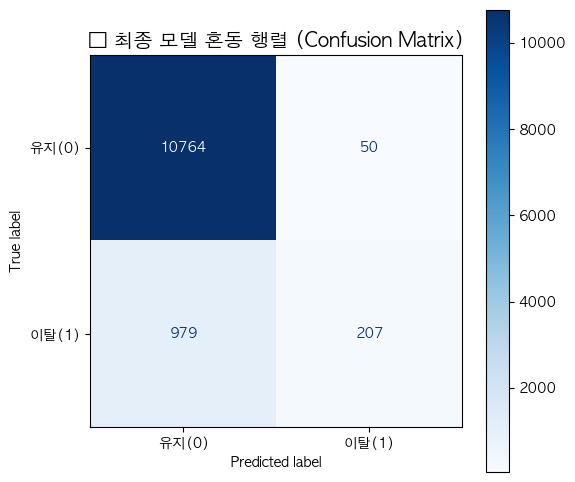

In [19]:
# ==============================================================================
# 📊 [시각화 2] 오탐지를 한 눈에! (혼동 행렬)
# ==============================================================================
# 임계값을 0.5로 설정하여 이탈 여부 판별
cm = confusion_matrix(y_valid, (valid_preds > 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['유지(0)', '이탈(1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('🔍 최종 모델 혼동 행렬 (Confusion Matrix)', fontsize=14)
plt.show()

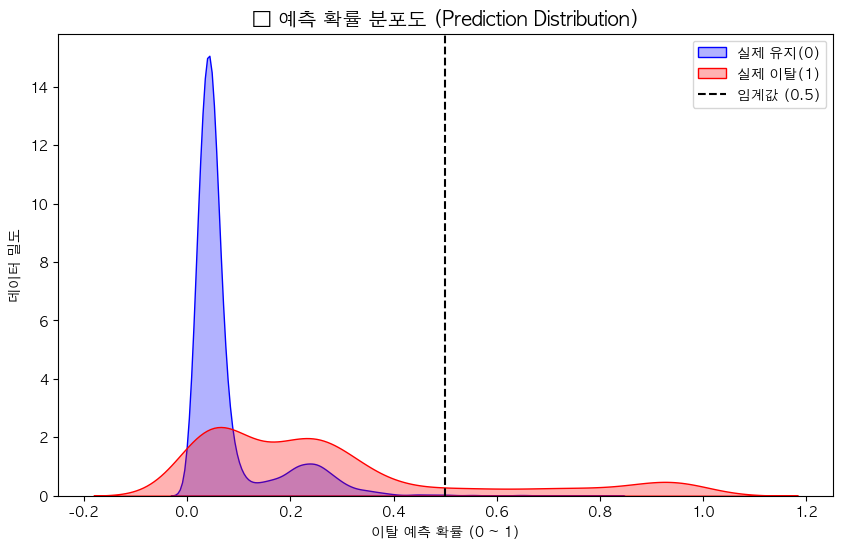

In [21]:
# ==============================================================================
# 📊 [시각화 3] 모델의 확신도! (예측 확률 분포도)
# ==============================================================================
plt.figure(figsize=(10, 6))
sns.kdeplot(valid_preds[y_valid == 0], color='blue', fill=True, label='실제 유지(0)', alpha=0.3)
sns.kdeplot(valid_preds[y_valid == 1], color='red', fill=True, label='실제 이탈(1)', alpha=0.3)
plt.axvline(0.5, color='black', linestyle='--', label='임계값 (0.5)')

plt.title('📈 예측 확률 분포도 (Prediction Distribution)', fontsize=14)
plt.xlabel('이탈 예측 확률 (0 ~ 1)')
plt.ylabel('데이터 밀도')
plt.legend()
plt.show()